In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Paths to the CSV files
true_labels_path = r'C:\MyFolders\Projects\major_project\classification\dataset\aptos_resized_kaggle\aug_split_data\test_true_labels2.csv'  # Update this path
predicted_labels_path = r'C:\MyFolders\Projects\major_project\classification\codes\aptos\pred_label_squeezenet.csv'  # Update this path

# Load true and predicted labels from CSVs
true_df = pd.read_csv(true_labels_path)
pred_df = pd.read_csv(predicted_labels_path)

# Ensure that both dataframes have the same length
assert len(true_df) == len(pred_df), "Mismatch in number of true and predicted labels."

# Extract the true labels and predicted labels
y_true = true_df['diagnosis'].values  # True labels column in CSV
y_pred = pred_df['predicted_diagnosis'].values  # Predicted labels column in CSV

# Create the confusion matrix
cm = confusion_matrix(y_true, y_pred)
class_names = ['No_DR', 'Mild', 'Moderate', 'Severe', 'Proliferate_DR']  # Modify based on your classes

# Print classification report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))



Classification Report:

                precision    recall  f1-score   support

         No_DR       0.01      0.00      0.00       303
          Mild       0.09      0.14      0.11       195
      Moderate       0.02      0.03      0.03       245
        Severe       0.00      0.00      0.00       179
Proliferate_DR       0.01      0.01      0.01       188

      accuracy                           0.03      1110
     macro avg       0.02      0.04      0.03      1110
  weighted avg       0.02      0.03      0.03      1110



Found 1110 images belonging to 5 classes.
35/35 [==============================] - 4s 46ms/step


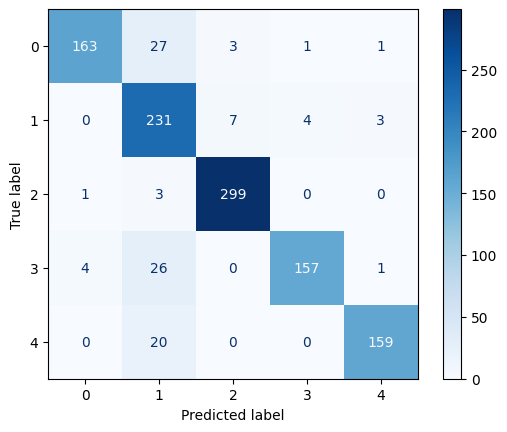

In [3]:
# Assuming you have your model loaded and your test data prepared
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Load your model
model = tf.keras.models.load_model(r'C:\MyFolders\Projects\major_project\classification\codes\aptos\squeezenet_aug.h5')

# Prepare your test data (assuming it's in a directory structure similar to your training data)
test_datagen = ImageDataGenerator(rescale=1.0/255.0)
test_generator = test_datagen.flow_from_directory(
    r'C:\MyFolders\Projects\major_project\classification\dataset\aptos_resized_kaggle\aug_split_data\test',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False  # Important for obtaining the correct order of predictions
)

# Get true labels
true_labels = test_generator.classes

# Make predictions
predictions = model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)

# Now you can create the confusion matrix using the true_labels and predicted_classes
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(true_labels, predicted_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.show()


In [5]:
# Generate the classification report
report = classification_report(
    true_labels,
    predicted_classes,
    target_names=['No_DR', 'Mild', 'Moderate', 'Severe', 'Proliferate_DR']
)
print(report)

                precision    recall  f1-score   support

         No_DR       0.97      0.84      0.90       195
          Mild       0.75      0.94      0.84       245
      Moderate       0.97      0.99      0.98       303
        Severe       0.97      0.84      0.90       188
Proliferate_DR       0.97      0.89      0.93       179

      accuracy                           0.91      1110
     macro avg       0.93      0.90      0.91      1110
  weighted avg       0.92      0.91      0.91      1110



In [6]:
unique, counts = np.unique(true_labels, return_counts=True)
class_distribution = dict(zip(unique, counts))
print("True class distribution:", class_distribution)


True class distribution: {0: 195, 1: 245, 2: 303, 3: 188, 4: 179}


In [7]:
unique_pred, counts_pred = np.unique(predicted_classes, return_counts=True)
predicted_distribution = dict(zip(unique_pred, counts_pred))
print("Predicted class distribution:", predicted_distribution)


Predicted class distribution: {0: 168, 1: 307, 2: 309, 3: 162, 4: 164}


In [10]:
predicted_classes = np.argmax(predictions, axis=1)
print(predicted_classes)

[0 0 0 ... 4 4 4]


In [16]:
import os

# Path to the test dataset directory
test_data_path = r'C:\MyFolders\Projects\major_project\classification\dataset\aptos_resized_kaggle\aug_split_data\test'  # Update this with your actual path

# List all directories (class folders)
try:
    class_dirs = os.listdir(test_data_path)
    print("Class directories found in test data path:")
    for class_dir in class_dirs:
        print(class_dir)
except FileNotFoundError:
    print("The specified test data path does not exist.")


Class directories found in test data path:
Mild
Moderate
No_DR
Proliferate_DR
Severe


In [17]:
class_mapping = {
    'No_DR': 0,
    'Mild': 1,
    'Moderate': 2,
    'Severe': 3,
    'Proliferate_DR': 4
}
from sklearn.metrics import classification_report

# Assuming true_labels and predicted_classes are already defined
# They should contain numerical labels (0, 1, 2, 3, 4)

# Generate the classification report
report = classification_report(
    true_labels,  # True labels (integers 0-4)
    predicted_classes,  # Predicted labels (integers 0-4)
    target_names=list(class_mapping.keys())  # Use class names as labels
)

print(report)


                precision    recall  f1-score   support

         No_DR       0.97      0.84      0.90       195
          Mild       0.75      0.94      0.84       245
      Moderate       0.97      0.99      0.98       303
        Severe       0.97      0.84      0.90       188
Proliferate_DR       0.97      0.89      0.93       179

      accuracy                           0.91      1110
     macro avg       0.93      0.90      0.91      1110
  weighted avg       0.92      0.91      0.91      1110



In [18]:
from sklearn.metrics import classification_report

# Generate the classification report
report = classification_report(
    true_labels,
    predicted_classes,
    target_names=['No_DR', 'Mild', 'Moderate', 'Severe', 'Proliferate_DR']  # Use class names
)

print(report)


                precision    recall  f1-score   support

         No_DR       0.97      0.84      0.90       195
          Mild       0.75      0.94      0.84       245
      Moderate       0.97      0.99      0.98       303
        Severe       0.97      0.84      0.90       188
Proliferate_DR       0.97      0.89      0.93       179

      accuracy                           0.91      1110
     macro avg       0.93      0.90      0.91      1110
  weighted avg       0.92      0.91      0.91      1110



In [21]:
print("True labels:", true_labels[:10])  # Print the first 10 true labels
print("Predicted labels:", predicted_classes[:10])  # Print the first 10 predicted labels
print("Number of true labels:", len(true_labels))
print("Number of predicted labels:", len(predicted_classes))


True labels: [0 0 0 0 0 0 0 0 0 0]
Predicted labels: [0 0 0 0 0 0 0 0 0 1]
Number of true labels: 1110
Number of predicted labels: 1110


In [24]:
class_mapping = {
    'Mild': 1,
    'Moderate': 2,
    'No_DR': 0,
    'Proliferate_DR': 4,
    'Severe': 3
}

from sklearn.metrics import classification_report

# Assuming true_labels and predicted_classes are numerical values (0-4)
report = classification_report(
    true_labels,
    predicted_classes,
    target_names=list(class_mapping.keys())  
)

print(report)


                precision    recall  f1-score   support

          Mild       0.97      0.84      0.90       195
      Moderate       0.75      0.94      0.84       245
         No_DR       0.97      0.99      0.98       303
Proliferate_DR       0.97      0.84      0.90       188
        Severe       0.97      0.89      0.93       179

      accuracy                           0.91      1110
     macro avg       0.93      0.90      0.91      1110
  weighted avg       0.92      0.91      0.91      1110



In [25]:
# If using alphabetical order:
class_mapping = {
    'Mild': 0,
    'Moderate': 1,
    'No_DR': 2,
    'Proliferate_DR': 3,
    'Severe': 4
}

# But if you want the desired mapping:
desired_mapping = {
    'No_DR': 0,
    'Mild': 1,
    'Moderate': 2,
    'Severe': 3,
    'Proliferate_DR': 4
}

# To ensure your true and predicted labels correspond correctly:
true_labels_corrected = [desired_mapping[list(class_mapping.keys())[label]] for label in true_labels]
predicted_classes_corrected = [desired_mapping[list(class_mapping.keys())[label]] for label in predicted_classes]


In [26]:
report = classification_report(
    true_labels_corrected,
    predicted_classes_corrected,
    target_names=list(desired_mapping.keys())
)

print(report)


                precision    recall  f1-score   support

         No_DR       0.97      0.99      0.98       303
          Mild       0.97      0.84      0.90       195
      Moderate       0.75      0.94      0.84       245
        Severe       0.97      0.89      0.93       179
Proliferate_DR       0.97      0.84      0.90       188

      accuracy                           0.91      1110
     macro avg       0.93      0.90      0.91      1110
  weighted avg       0.92      0.91      0.91      1110



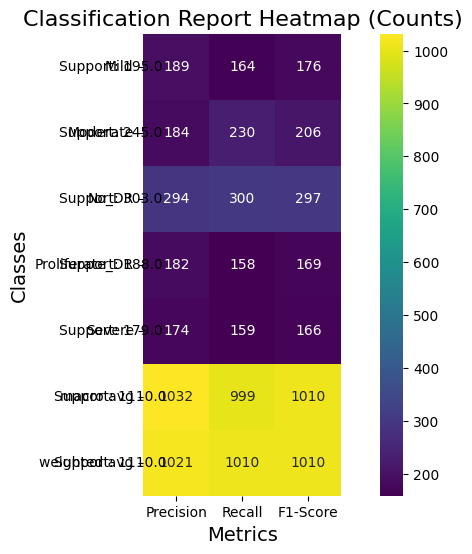

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Your classification report data
report = {
    'Mild': {'precision': 0.97, 'recall': 0.84, 'f1-score': 0.90, 'support': 195},
    'Moderate': {'precision': 0.75, 'recall': 0.94, 'f1-score': 0.84, 'support': 245},
    'No_DR': {'precision': 0.97, 'recall': 0.99, 'f1-score': 0.98, 'support': 303},
    'Proliferate_DR': {'precision': 0.97, 'recall': 0.84, 'f1-score': 0.90, 'support': 188},
    'Severe': {'precision': 0.97, 'recall': 0.89, 'f1-score': 0.93, 'support': 179},
    'accuracy': {'precision': None, 'recall': None, 'f1-score': None, 'support': 1110},
    'macro avg': {'precision': 0.93, 'recall': 0.90, 'f1-score': 0.91, 'support': 1110},
    'weighted avg': {'precision': 0.92, 'recall': 0.91, 'f1-score': 0.91, 'support': 1110}
}

# Convert the classification report to a DataFrame
report_df = pd.DataFrame(report).transpose()

# Remove the 'accuracy' row for visualization
report_df = report_df.drop('accuracy')

# Calculate counts for precision, recall, and f1-score
report_df['precision_count'] = (report_df['precision'] * report_df['support']).round().astype(int)
report_df['recall_count'] = (report_df['recall'] * report_df['support']).round().astype(int)
report_df['f1_count'] = (report_df['f1-score'] * report_df['support']).round().astype(int)

# Create a new DataFrame for heatmap display
heatmap_df = report_df[['precision_count', 'recall_count', 'f1_count']].copy()
heatmap_df.columns = ['Precision', 'Recall', 'F1-Score']

# Plotting the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_df, annot=True, fmt="d", cmap='viridis', cbar=True, square=True)
plt.title('Classification Report Heatmap (Counts)', fontsize=16)
plt.xlabel('Metrics', fontsize=14)
plt.ylabel('Classes', fontsize=14)
plt.xticks(rotation=0)

# Show support as a separate annotation
for i in range(len(report_df)):
    plt.text(-0.5, i + 0.5, f"Support: {report_df['support'].iloc[i]}", ha='center', va='center', color='black')

plt.show()


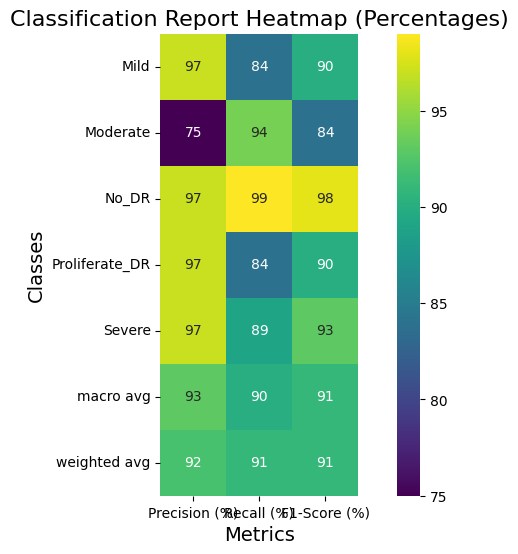

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Your classification report data
report = {
    'Mild': {'precision': 0.97, 'recall': 0.84, 'f1-score': 0.90, 'support': 195},
    'Moderate': {'precision': 0.75, 'recall': 0.94, 'f1-score': 0.84, 'support': 245},
    'No_DR': {'precision': 0.97, 'recall': 0.99, 'f1-score': 0.98, 'support': 303},
    'Proliferate_DR': {'precision': 0.97, 'recall': 0.84, 'f1-score': 0.90, 'support': 188},
    'Severe': {'precision': 0.97, 'recall': 0.89, 'f1-score': 0.93, 'support': 179},
    'accuracy': {'precision': None, 'recall': None, 'f1-score': None, 'support': 1110},
    'macro avg': {'precision': 0.93, 'recall': 0.90, 'f1-score': 0.91, 'support': 1110},
    'weighted avg': {'precision': 0.92, 'recall': 0.91, 'f1-score': 0.91, 'support': 1110}
}

# Convert the classification report to a DataFrame
report_df = pd.DataFrame(report).transpose()

# Remove the 'accuracy' row for visualization
report_df = report_df.drop('accuracy')

# Convert metrics to percentages and round to integer
report_df['precision'] = (report_df['precision'] * 100).round().astype(int)
report_df['recall'] = (report_df['recall'] * 100).round().astype(int)
report_df['f1-score'] = (report_df['f1-score'] * 100).round().astype(int)

# Create a new DataFrame for heatmap display
heatmap_df = report_df[['precision', 'recall', 'f1-score']].copy()
heatmap_df.columns = ['Precision (%)', 'Recall (%)', 'F1-Score (%)']

# Plotting the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_df, annot=True, fmt="d", cmap='viridis', cbar=True, square=True)
plt.title('Classification Report Heatmap (Percentages)', fontsize=16)
plt.xlabel('Metrics', fontsize=14)
plt.ylabel('Classes', fontsize=14)
plt.xticks(rotation=0)

# # Show support as a separate annotation
# for i in range(len(report_df)):
#     plt.text(-0.5, i + 0.5, f"Support: {report_df['support'].iloc[i]}", ha='center', va='center', color='black')

plt.show()


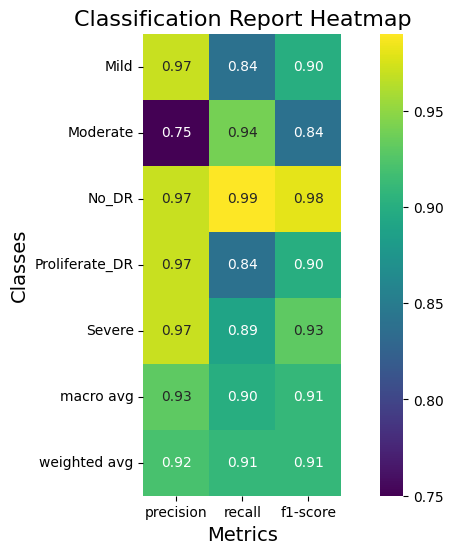

In [2]:
#CORRECT
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Your classification report data
report = {
    'Mild': {'precision': 0.97, 'recall': 0.84, 'f1-score': 0.90, 'support': 195},
    'Moderate': {'precision': 0.75, 'recall': 0.94, 'f1-score': 0.84, 'support': 245},
    'No_DR': {'precision': 0.97, 'recall': 0.99, 'f1-score': 0.98, 'support': 303},
    'Proliferate_DR': {'precision': 0.97, 'recall': 0.84, 'f1-score': 0.90, 'support': 188},
    'Severe': {'precision': 0.97, 'recall': 0.89, 'f1-score': 0.93, 'support': 179},
    'accuracy': {'precision': None, 'recall': None, 'f1-score': None, 'support': 1110},
    'macro avg': {'precision': 0.93, 'recall': 0.90, 'f1-score': 0.91, 'support': 1110},
    'weighted avg': {'precision': 0.92, 'recall': 0.91, 'f1-score': 0.91, 'support': 1110}
}

# Convert the classification report to a DataFrame
report_df = pd.DataFrame(report).transpose()

# Remove the 'accuracy' row for visualization
report_df = report_df.drop('accuracy')

# Plotting the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(report_df.iloc[:, :-1], annot=True, fmt=".2f", cmap='viridis', cbar=True, square=True)
plt.title('Classification Report Heatmap', fontsize=16)
plt.xlabel('Metrics', fontsize=14)
plt.ylabel('Classes', fontsize=14)
plt.xticks(rotation=0)
plt.show()


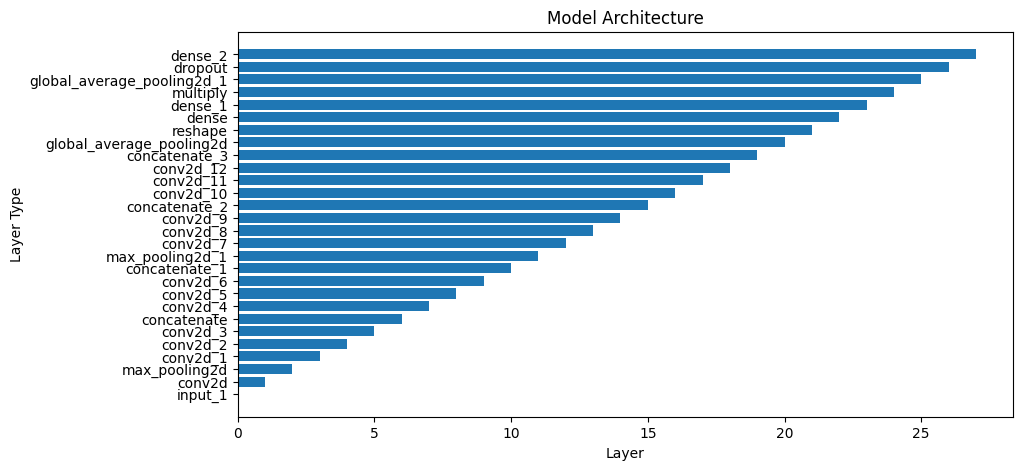

In [17]:
import matplotlib.pyplot as plt

def plot_layers(model):
    layer_names = [layer.name for layer in model.layers]
    layer_types = [type(layer).__name__ for layer in model.layers]
    
    plt.figure(figsize=(10, 5))
    plt.title("Model Architecture")
    plt.xlabel("Layer")
    plt.ylabel("Layer Type")
    plt.barh(layer_names, range(len(layer_names)))
    
    # for i, layer_name in enumerate(layer_names):
    #     plt.text(0.5, i, f"{layer_name} ({layer_types[i]})", horizontalalignment="center")
    
    plt.show()

# Load your model
model = tf.keras.models.load_model(r'C:\MyFolders\Projects\major_project\classification\codes\aptos\squeezenet2_try.h5')

# Display the model layers
plot_layers(model)


In [19]:
import os

def count_images_in_directory(directory_path):
    total_images = 0
    for root, _, files in os.walk(directory_path):
        image_files = [f for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif'))]
        total_images += len(image_files)
    return total_images

# Define paths to your datasets
train_dir = r'C:\MyFolders\Projects\major_project\classification\dataset\aptos_resized_kaggle\aug_split_data\train'
test_dir = r'C:\MyFolders\Projects\major_project\classification\dataset\aptos_resized_kaggle\aug_split_data\test'
val_dir = r'C:\MyFolders\Projects\major_project\classification\dataset\aptos_resized_kaggle\aug_split_data\val'

# Count images in each dataset
num_train_images = count_images_in_directory(train_dir)
num_test_images = count_images_in_directory(test_dir)
num_val_images = count_images_in_directory(val_dir)

# Print the results
print(f'Number of images in the training dataset: {num_train_images}')
print(f'Number of images in the test dataset: {num_test_images}')
print(f'Number of images in the validation dataset: {num_val_images}')


Number of images in the training dataset: 8883
Number of images in the test dataset: 1110
Number of images in the validation dataset: 1113
